In [1]:
import sys
import os
# Adds the parent directory to sys.path
sys.path.append(os.path.abspath('..'))
import pandas as pd
from utils import (data_encoder, hyper_param_opt,
                   outlier_detection_by_clust,
                   weighted_distance_calculation,
                   outlier_detection_by_dist,
                   final_plot)
import pickle


In [5]:
dataset_name= 'health'


In [2]:
def privgen(data, dataset_name):
    """
    This function exist just for development purposes
    In the actual tool, each of the steps of this functions are individual functions
    which should be ran consequently
    The plots that come out of this functions are those created by the intermediate steps
    and theretically speaking, should help the user to choose the parameters
    """

    # ENCODING
    # This is an auxilary function which is not done by the user
    encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)

    # GRID-SEARCH
    hyper_param_opt.hyper_param_search(
        encoded_data,
        percentage_outliers=0.1,
        dataset_name=dataset_name,
        top_n=10,
        eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
        min_samples_values=range(30, 50),
        save=True)

    # REMOVE DBSCAN OUTLIERS
    # The arguments of this funciton (now hard-coded) should be choosen by the user, 
    # based on the output of the previous step
    outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=33,
                                                            metric='euclidean', algorithm='auto',
                                                            leaf_size=50, dataset_name=dataset_name, p=2, plot=False)

    # GET DISTRIBUTIONS
    weighted_distance_calculation.calculate_plot_distance(dataset_name)

    # REMOVE DISTANT OUTLIERS
    # The thresholds (now hard-coded) should be choosen by the user, 
    # based on the output of the previous step
    threshold = {'0': 30000, '1': 30000, '2': 30000, '3': 30000, '4': 30000, '5': 15000,
                 '6': 21000, '7': 25000, '8': 12000, '9': 25000, '10': 20000, '11': 20000, '12': 22000}

    outlier_detection_by_dist.filter_and_save_by_distance(
        dataset_name, threshold, plot=False)

    # PLOT
    final_plot.plot_data_points(dataset_name)

    # DECODING
    # This is an auxilary function which is not done by the user
    decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)

    return decoded_data

In [3]:
 # as the name suggest this dataset was created just as a toy example
# inside privgen_generate.ipynb notebook you can find a funciton called download_dataset
# which can be used to download specific datasets from UCI database
data = pd.read_csv('../datasets/healthinsurance.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


## Imputation

In [6]:
from sklearn.impute import SimpleImputer

cols = data.columns
imp = SimpleImputer(strategy="most_frequent")
data = pd.DataFrame(imp.fit_transform(data))
data.columns = cols

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  15000 non-null  object
 1   sex                  15000 non-null  object
 2   weight               15000 non-null  object
 3   bmi                  15000 non-null  object
 4   hereditary_diseases  15000 non-null  object
 5   no_of_dependents     15000 non-null  object
 6   smoker               15000 non-null  object
 7   city                 15000 non-null  object
 8   bloodpressure        15000 non-null  object
 9   diabetes             15000 non-null  object
 10  regular_ex           15000 non-null  object
 11  job_title            15000 non-null  object
 12  claim                15000 non-null  object
dtypes: object(13)
memory usage: 1.5+ MB


In [22]:
cols_to_int = ['age', 'weight', 'no_of_dependents', 'bloodpressure']
for col in cols_to_int:
    data[col] = data[col].astype(int)

data['bmi'] = data['bmi'].astype(float)

## Encoding

In [ ]:
encoded_data = data_encoder.ordinal_encode_categorical(
        data, dataset_name, save=True)


In [24]:
encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  int64  
 1   sex                  15000 non-null  float64
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  float64
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  float64
 7   city                 15000 non-null  float64
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  float64
 10  regular_ex           15000 non-null  float64
 11  job_title            15000 non-null  float64
 12  claim                15000 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 1.5 MB


## DBSCAN HyperParameter Optimization

In [9]:

#     # GRID-SEARCH
# hyper_param_opt.hyper_param_search(
#     encoded_data,
#     percentage_outliers=0.1,
#     dataset_name=dataset_name,
#     top_n=10,
#     eps_values=[0.7, 0.8, 0.9, 1., 1.5, 2],
#     min_samples_values=range(30, 50),
#     save=True)

# WAS DONe ON A EC2 MACHINE

In [25]:
import pandas as pd
gs = pd.read_csv('../data/health_grid_search_results.csv')

In [26]:
gs.describe()

,num_clusters,percentage_outliers,eps,min_samples,leaf_size,p,silhouette_score
count,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,14400.000000,21600.000000
mean,3.733333,0.862276,1.150000,39.500000,30.000000,1.500000,-0.577006
std,5.514352,0.258244,0.457358,5.766415,14.142463,0.500017,0.442130
min,0.000000,0.169600,0.700000,30.000000,10.000000,1.000000,-1.000000
25%,0.000000,0.957283,0.800000,34.750000,20.000000,1.000000,-1.000000
50%,0.000000,1.000000,0.950000,39.500000,30.000000,1.500000,-1.000000
75%,4.000000,1.000000,1.500000,44.250000,40.000000,2.000000,-0.156207
max,19.000000,1.000000,2.000000,49.000000,50.000000,2.000000,0.055801


# Choosing the best params

In [27]:
gs.sort_values(['silhouette_score','num_clusters', 'percentage_outliers'], ascending=[False, False, True])

,num_clusters,percentage_outliers,eps,min_samples,metric,algorithm,leaf_size,p,silhouette_score
21060,9,0.232333,2.0,47,euclidean,auto,10,NaN,0.055801
21061,9,0.232333,2.0,47,euclidean,auto,10,1.0,0.055801
21062,9,0.232333,2.0,47,euclidean,auto,10,2.0,0.055801
21063,9,0.232333,2.0,47,euclidean,auto,20,NaN,0.055801
21064,9,0.232333,2.0,47,euclidean,auto,20,1.0,0.055801
...,...,...,...,...,...,...,...,...,...
17935,0,1.000000,1.5,49,manhattan,brute,40,1.0,-1.000000
17936,0,1.000000,1.5,49,manhattan,brute,40,2.0,-1.000000
17937,0,1.000000,1.5,49,manhattan,brute,50,NaN,-1.000000
17938,0,1.000000,1.5,49,manhattan,brute,50,1.0,-1.000000


## REMOVE DBSCAN OUTLIERS



In [28]:
outlier_detection_by_clust.create_dbscan_and_clean_data(encoded_data, eps=2, min_samples=47,
                                                        metric='euclidean', algorithm='auto',
                                                        leaf_size=10, dataset_name=dataset_name, p=1, plot=False)


Percentage of outliers removed: 23.23%
Number of clusters found: 9


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,cluster
0,60,1.0,64,24.3,8.0,1,0.0,55.0,72,0.0,0.0,2.0,1081.0,2
1,49,0.0,75,22.6,8.0,1,0.0,5.0,78,1.0,1.0,16.0,775.0,4
2,61,0.0,53,36.4,8.0,1,1.0,64.0,72,1.0,0.0,10.0,2035.0,0
3,19,0.0,50,20.6,8.0,0,0.0,8.0,82,1.0,0.0,22.0,61.0,1
4,42,0.0,89,37.9,8.0,0,0.0,1.0,78,0.0,0.0,12.0,502.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11510,39,1.0,49,28.3,8.0,1,1.0,24.0,54,1.0,0.0,20.0,1496.0,8
11511,39,1.0,74,29.6,8.0,4,0.0,49.0,64,1.0,0.0,33.0,602.0,3
11512,20,1.0,62,33.3,8.0,0,0.0,82.0,52,1.0,0.0,18.0,19.0,3
11513,52,1.0,88,36.7,8.0,0,0.0,61.0,70,1.0,0.0,17.0,742.0,3



## GET DISTRIBUTIONS


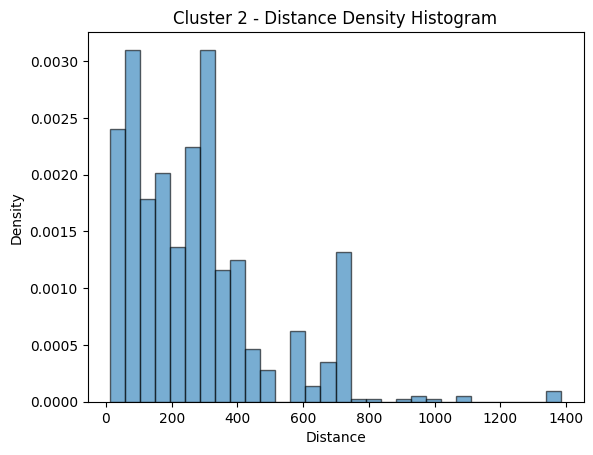

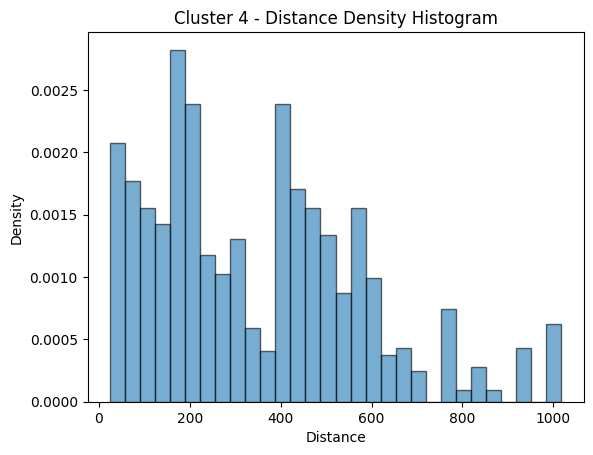

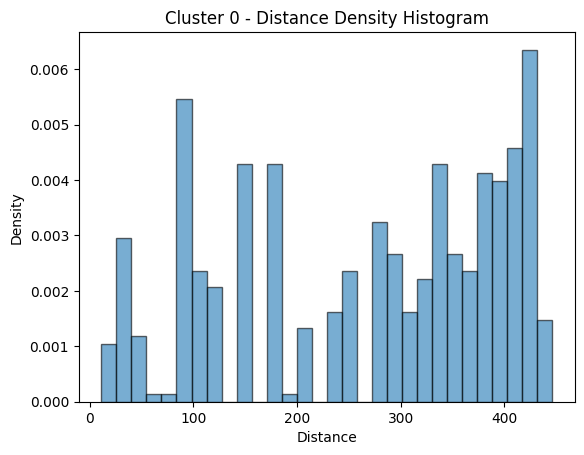

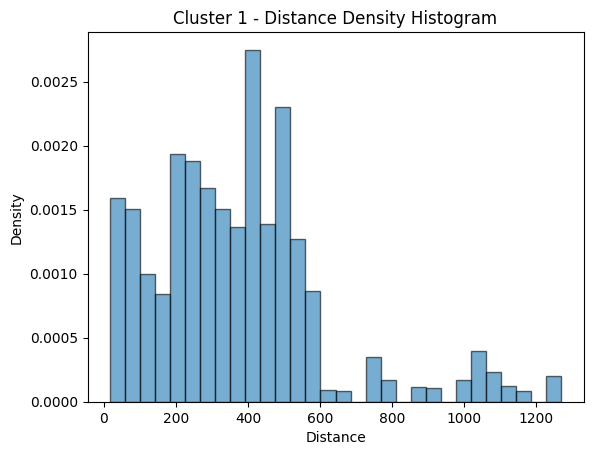

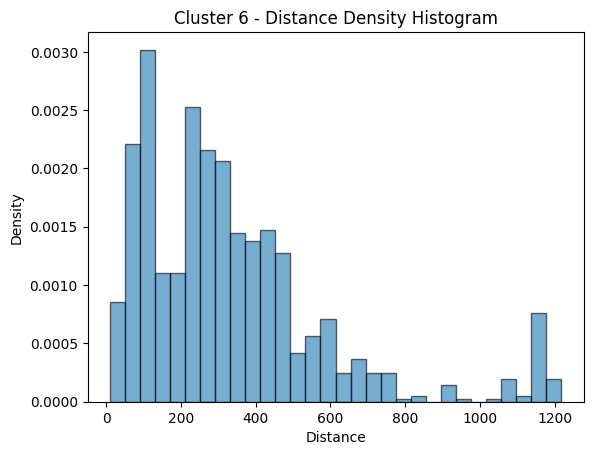

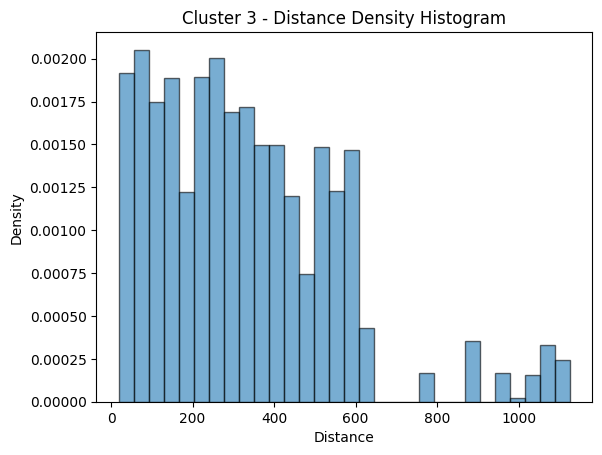

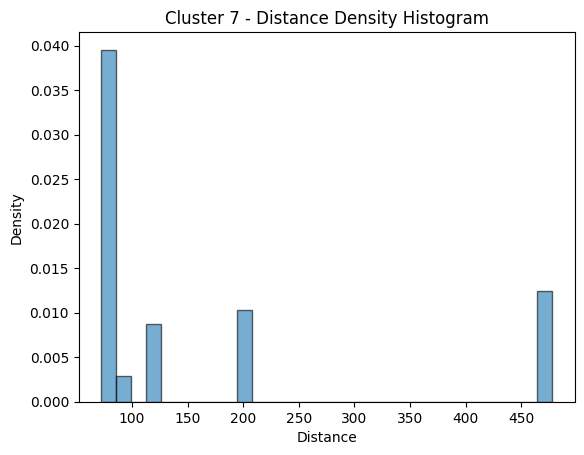

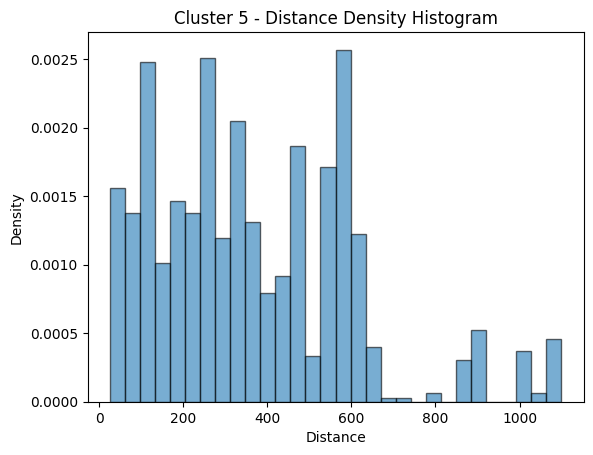

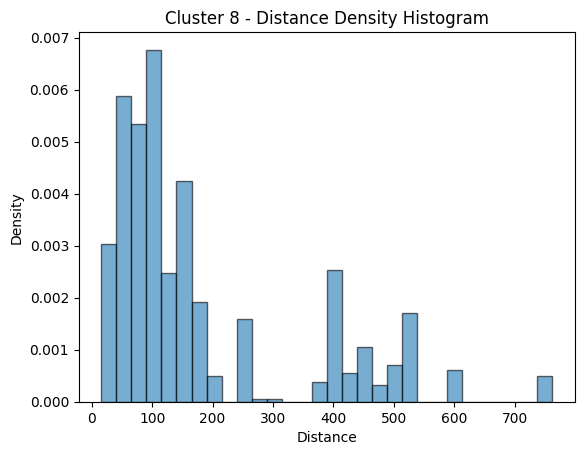

In [29]:
weighted_distance_calculation.calculate_plot_distance(dataset_name)



## REMOVE DISTANT OUTLIERS


In [30]:
threshold = {'0': 450, '1': 600, '2':800 , '3':600, '4':800, '5':700, '6':800 , '7':200, '8': 500 }

outlier_detection_by_dist.filter_and_save_by_distance(
    dataset_name, threshold, plot=False)



## PLOT


/Users/navid/Documents/0_Research/0_venues/Privgen/utils/final_plot.py:56: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(outliers_distance['feature_0'], outliers_distance['feature_1'],


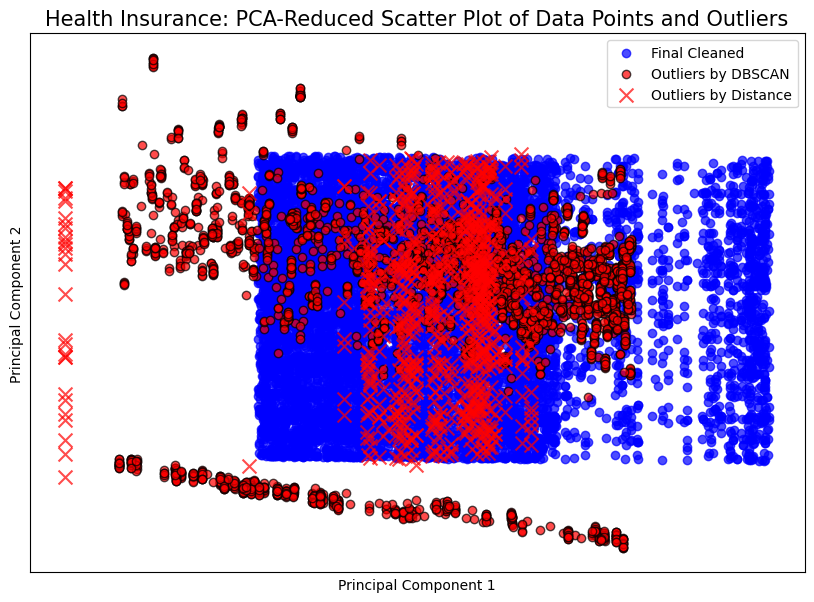

In [8]:
final_plot.plot_data_points(dataset_name, 'Health Insurance')



## DECODING


In [32]:
decoded_data = data_encoder.ordinal_decode_categorical(dataset_name)

In [ ]:
https://portali.giustizia-amministrativa.it/portale/pages/istituzionale/visualizza